# Week 5: Sequential Call Centre Classification

**Project:** AI-Based Smart Queue & Time Management System  
**Course:** TECH 405  
**Target:** `meets_standard` (True = 1, False = 0)

This notebook builds an actual PyTorch LSTM classifier from the call-centre event stream. It constructs within-day windows from chronological calls; the source CSV does not contain pre-built sequences.

## Objective and framing

The data consists of ordered call events but not sequence labels. Calls for a given day have similar queue conditions; therefore, this notebook creates an overlapping window with 20 calls from the same operating date and predicts whether the next call meets the service standard. Windows do not overlap across dates since the simulation starts a new caller count for the day and includes non-operating days.

This is a **next event classification problem**, and not an assertion that the CSV contains sequence labels. The 20-calls context is defined beforehand; the last 20% of calls by chronology are reserved for testing in the future. Model parameters are tuned using only the chronological validation slice in the first 80%.

### Leakage and information at prediction time

`meets_standard` is the label. Analysis shows that `wait_length <= 60` perfectly predicts the label, meaning `wait_length` is a leakage of the label and is dropped. Features `call_answered`, `call_ended`, `service_length`, and `call_id` are excluded as post-arrival/post-service and identifiers. Only the daily caller count of the previous calls and features created from their arrival times are used as inputs. There is no official target accuracy for this dataset.

### Week 5 Objectives

- Create a real `nn.LSTM` followed by `nn.Linear` in PyTorch, without using a pre-trained model.
- Compute a majority class baseline for training and comparing against the unseen test set.
- Tune a few model configurations on the validation set only.
- Report the test accuracy, confusion matrix, precision, recall, and F1 score honestly, with any caveats.

**Sequence Length:** 20 previous calls is a short recent history window. The data contains between 115 and 297 calls per day; therefore, this window is still representative of the local queue context and provides many training samples. This is decided beforehand and is not tuned against the test set.

In [1]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\MSI-1\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\MSI-1\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


PyTorch: 2.6.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Load and inspect the actual dataset

The audit performed below reconstructs the calculations for the shape, columns, data types, date span, null values, duplicate records, target balance, numeric statistics, and chronological sorting from the CSV file.

In [2]:
EXPECTED_COLUMNS = [
    "call_id", "date", "daily_caller", "call_started", "call_answered",
    "call_ended", "wait_length", "service_length", "meets_standard",
]
SEQUENCE_LENGTH = 20

possible_paths = [Path("../data/simulated_call_centre.csv"), Path("data/simulated_call_centre.csv")]
DATA_PATH = next((path for path in possible_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find data/simulated_call_centre.csv from the notebook or project root.")

raw_df = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw_df.columns))
if missing_columns:
    raise ValueError(f"Dataset is missing expected columns: {missing_columns}")

raw_df["started_at"] = pd.to_datetime(
    raw_df["date"].astype(str) + " " + raw_df["call_started"].astype(str),
    format="%Y-%m-%d %I:%M:%S %p",
    errors="coerce",
)
if raw_df["started_at"].isna().any():
    raise ValueError("Some date/call_started values could not be parsed.")

raw_df = raw_df.sort_values(["started_at", "call_id"], kind="mergesort").reset_index(drop=True)
raw_df["target"] = raw_df["meets_standard"].map({True: 1, False: 0}).astype("int64")
raw_df["row_position"] = np.arange(len(raw_df), dtype=np.int64)

print(f"Dataset: {DATA_PATH.resolve()}")
print(f"Shape: {raw_df.shape[0]:,} rows x {len(EXPECTED_COLUMNS)} source columns")
print("Columns:", EXPECTED_COLUMNS)
print("Source dtypes:\n", raw_df[EXPECTED_COLUMNS].dtypes.to_string())
print("Missing values:\n", raw_df[EXPECTED_COLUMNS].isna().sum().to_string())
print(f"Duplicate source rows: {raw_df[EXPECTED_COLUMNS].duplicated().sum():,}")
print(f"Date range: {raw_df['started_at'].min()} to {raw_df['started_at'].max()}")
print(f"Chronological after stable sort: {raw_df['started_at'].is_monotonic_increasing}")
print(f"Rows were already chronological in source: {pd.to_datetime(pd.read_csv(DATA_PATH)['date'].astype(str) + ' ' + pd.read_csv(DATA_PATH)['call_started'].astype(str), format='%Y-%m-%d %I:%M:%S %p').is_monotonic_increasing}")
print(f"Operating dates: {raw_df['date'].nunique()}")
print("Rows per date (min/median/max):", int(raw_df.groupby("date").size().min()), int(raw_df.groupby("date").size().median()), int(raw_df.groupby("date").size().max()))
print("Target counts:\n", raw_df["meets_standard"].value_counts().rename(index={True: "True (1)", False: "False (0)"}).to_string())
print("Target proportions:\n", raw_df["meets_standard"].value_counts(normalize=True).rename(index={True: "True (1)", False: "False (0)"}).round(6).to_string())
print("Numeric feature/source distributions:\n", raw_df[["daily_caller", "wait_length", "service_length"]].describe().round(2).to_string())
print("Time-column examples:\n", raw_df[["date", "call_started", "call_answered", "call_ended"]].head(3).to_string(index=False))

wait_label_check = (raw_df["wait_length"] <= 60).eq(raw_df["target"])
print(f"Wait threshold matches target for every row: {wait_label_check.all()} ({wait_label_check.mean():.1%} of rows)")

Dataset: C:\Users\MSI-1\OneDrive\Desktop\Smart Queue & Time Management System\data\simulated_call_centre.csv
Shape: 51,708 rows x 9 source columns
Columns: ['call_id', 'date', 'daily_caller', 'call_started', 'call_answered', 'call_ended', 'wait_length', 'service_length', 'meets_standard']
Source dtypes:
 call_id           int64
date                str
daily_caller      int64
call_started        str
call_answered       str
call_ended          str
wait_length       int64
service_length    int64
meets_standard     bool
Missing values:
 call_id           0
date              0
daily_caller      0
call_started      0
call_answered     0
call_ended        0
wait_length       0
service_length    0
meets_standard    0
Duplicate source rows: 0
Date range: 2021-01-01 08:00:00 to 2021-12-31 17:58:15
Chronological after stable sort: True
Rows were already chronological in source: True
Operating dates: 261
Rows per date (min/median/max): 115 193 297
Target counts:
 meets_standard
True (1)     47481


## Data cleaning checks

The data audit found no missing values or exact duplicate rows, so no records need to be removed or imputed. The checks below make that assumption executable: unexpected missing values or duplicates stop the notebook for review rather than being silently repaired.

In [3]:
missing_count = int(raw_df[EXPECTED_COLUMNS].isna().sum().sum())
duplicate_count = int(raw_df[EXPECTED_COLUMNS].duplicated().sum())
if missing_count:
    raise ValueError(f"Data cleaning required: found {missing_count} missing source values.")
if duplicate_count:
    raise ValueError(f"Data cleaning required: found {duplicate_count} duplicate source rows.")
print("Cleaning result: no rows dropped or imputed; all required source fields are complete and source rows are unique.")

Cleaning result: no rows dropped or imputed; all required source fields are complete and source rows are unique.


In [4]:
operating_days = pd.to_datetime(raw_df["date"].drop_duplicates(), format="%Y-%m-%d").sort_values()
non_operating_gaps = operating_days.diff().dropna()
caller_starts = raw_df.groupby("date", sort=False)["daily_caller"].first()
print(f"Gaps between operating dates longer than one day: {(non_operating_gaps > pd.Timedelta(days=1)).sum()}")
print(f"daily_caller starts at 1 on every date: {(caller_starts == 1).all()}")
print("daily_caller first values (first five operating dates):", caller_starts.head().tolist())

Gaps between operating dates longer than one day: 52
daily_caller starts at 1 on every date: True
daily_caller first values (first five operating dates): [1, 1, 1, 1, 1]


## Date/time preprocessing, leakage analysis, and feature selection

The current call's outcome and post-call durations are not inputs. For each historical call, the start time provides hour-of-day, time-of-day, weekday, calendar, and weekend context. `daily_caller` is retained as an arrival-time queue-position proxy. Cyclical encodings keep time-of-day and calendar cycles close at their boundaries.

In [5]:
TARGET_COLUMN = "target"

start_times = raw_df["started_at"]
minute_of_day = start_times.dt.hour * 60 + start_times.dt.minute
weekday = start_times.dt.dayofweek
month = start_times.dt.month

def cyclical_pair(values: pd.Series, period: float) -> tuple[np.ndarray, np.ndarray]:
    angle = 2.0 * np.pi * values.to_numpy(dtype=np.float32) / period
    return np.sin(angle), np.cos(angle)

hour_sin, hour_cos = cyclical_pair(start_times.dt.hour, 24)
minute_sin, minute_cos = cyclical_pair(minute_of_day, 1440)
weekday_sin, weekday_cos = cyclical_pair(weekday, 7)
day_sin, day_cos = cyclical_pair(start_times.dt.day - 1, 31)
month_sin, month_cos = cyclical_pair(month - 1, 12)

feature_df = pd.DataFrame({
    "daily_caller": raw_df["daily_caller"].astype(np.float32),
    "hour_sin": hour_sin,
    "hour_cos": hour_cos,
    "minute_of_day_sin": minute_sin,
    "minute_of_day_cos": minute_cos,
    "weekday_sin": weekday_sin,
    "weekday_cos": weekday_cos,
    "day_of_month_sin": day_sin,
    "day_of_month_cos": day_cos,
    "month_sin": month_sin,
    "month_cos": month_cos,
    "is_weekend": (weekday >= 5).astype(np.float32),
})
FEATURE_COLUMNS = feature_df.columns.tolist()
feature_matrix = feature_df.to_numpy(dtype=np.float32)
target_array = raw_df[TARGET_COLUMN].to_numpy(dtype=np.int64)
assert np.isfinite(feature_matrix).all(), "Feature matrix contains non-finite values."

print("Selected prediction-time features:", FEATURE_COLUMNS)
print("Excluded: call_id (identifier); wait_length (exact label leak); call_answered/call_ended/service_length (future outcomes).")
print("Feature matrix shape:", feature_matrix.shape)
print("Target vector shape:", target_array.shape)
print("Target mapping:", {"False": 0, "True": 1})

# Construct each window only from earlier calls on the same operating date.
window_positions_list = []
target_positions_list = []
for day_positions in raw_df.groupby("date", sort=False).indices.values():
    day_positions = np.asarray(day_positions, dtype=np.int64)
    for next_offset in range(SEQUENCE_LENGTH, len(day_positions)):
        window_positions_list.append(day_positions[next_offset - SEQUENCE_LENGTH:next_offset])
        target_positions_list.append(day_positions[next_offset])

window_positions = np.asarray(window_positions_list, dtype=np.int64)
target_positions = np.asarray(target_positions_list, dtype=np.int64)
X_raw = feature_matrix[window_positions]
y_all = target_array[target_positions]

print(f"Sequence length: {SEQUENCE_LENGTH} previous calls")
print(f"Constructed sequences: {len(X_raw):,}")
print("Sequence tensor shape:", X_raw.shape, "(samples, time steps, features)")
print("Sequence target shape:", y_all.shape)
print("First sequence's per-call context:\n", pd.DataFrame(X_raw[0], columns=FEATURE_COLUMNS).round(3).to_string(index=False))
print("First target is the following call's meets_standard:", int(y_all[0]))
assert X_raw.shape[1:] == (SEQUENCE_LENGTH, len(FEATURE_COLUMNS))
assert (window_positions < target_positions[:, None]).all(), "A sequence includes its target call or a future call."

Selected prediction-time features: ['daily_caller', 'hour_sin', 'hour_cos', 'minute_of_day_sin', 'minute_of_day_cos', 'weekday_sin', 'weekday_cos', 'day_of_month_sin', 'day_of_month_cos', 'month_sin', 'month_cos', 'is_weekend']
Excluded: call_id (identifier); wait_length (exact label leak); call_answered/call_ended/service_length (future outcomes).
Feature matrix shape: (51708, 12)
Target vector shape: (51708,)
Target mapping: {'False': 0, 'True': 1}
Sequence length: 20 previous calls
Constructed sequences: 46,488
Sequence tensor shape: (46488, 20, 12) (samples, time steps, features)
Sequence target shape: (46488,)
First sequence's per-call context:
  daily_caller  hour_sin  hour_cos  minute_of_day_sin  minute_of_day_cos  weekday_sin  weekday_cos  day_of_month_sin  day_of_month_cos  month_sin  month_cos  is_weekend
          1.0     0.866      -0.5              0.866             -0.500       -0.434       -0.901               0.0               1.0        0.0        1.0         0.0
     

In [6]:
target_dates = raw_df["date"].to_numpy()[target_positions]
window_dates = raw_df["date"].to_numpy()[window_positions]
assert (window_dates == target_dates[:, None]).all(), "A sequence crossed an operating-date boundary."
assert (np.diff(target_positions) > 0).all(), "Sequence targets are not chronologically ordered."
print("Verified: all context calls precede their targets, stay on the target date, and target calls remain chronologically ordered.")

Verified: all context calls precede their targets, stay on the target date, and target calls remain chronologically ordered.


**Snapshot 1: Dataset and sequence shapes before training.** This output shows the inspected source data, engineered feature matrix, binary target vector, one example 20-call input window, and its next-call label.

## Chronological 80/20 split, training/validation split, and scaling

The split boundary is based on the original ordered call rows: the first 80% of chronology is the development period, and targets in the final 20% form the future test period. The first 80% is then split chronologically into training and validation sequence targets. The test labels are not passed to model selection. `StandardScaler` is fitted only on unique feature rows appearing in training input windows, then applied to validation and test windows.

In [7]:
split_row = int(0.80 * len(raw_df))
train_pool_idx = np.flatnonzero(target_positions < split_row)
test_idx = np.flatnonzero(target_positions >= split_row)
validation_boundary_in_pool = int(0.80 * len(train_pool_idx))
train_idx = train_pool_idx[:validation_boundary_in_pool]
validation_idx = train_pool_idx[validation_boundary_in_pool:]

assert len(train_idx) and len(validation_idx) and len(test_idx)
assert target_positions[train_idx].max() < target_positions[validation_idx].min()
assert target_positions[validation_idx].max() < split_row <= target_positions[test_idx].min()

# Fit scaling statistics only from raw rows used by the optimization-training windows.
training_feature_positions = np.unique(window_positions[train_idx].reshape(-1))
scaler = StandardScaler()
scaler.fit(feature_matrix[training_feature_positions])
X_scaled = scaler.transform(X_raw.reshape(-1, len(FEATURE_COLUMNS))).reshape(X_raw.shape).astype(np.float32)

BATCH_SIZE = 64

def make_loader(indices: np.ndarray, shuffle: bool) -> DataLoader:
    x_tensor = torch.from_numpy(np.ascontiguousarray(X_scaled[indices]))
    y_tensor = torch.from_numpy(np.ascontiguousarray(y_all[indices], dtype=np.float32))
    dataset = TensorDataset(x_tensor, y_tensor)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

train_loader = make_loader(train_idx, shuffle=True)
validation_loader = make_loader(validation_idx, shuffle=False)
test_loader = make_loader(test_idx, shuffle=False)

train_class_counts = np.bincount(y_all[train_idx], minlength=2)
majority_class = int(train_class_counts.argmax())
train_majority_rate = float(train_class_counts[majority_class] / train_class_counts.sum())
validation_baseline_accuracy = float((y_all[validation_idx] == majority_class).mean())

print(f"Chronological raw-row cutoff (80%): {split_row:,} / {len(raw_df):,}")
print(f"Training sequence targets:   {len(train_idx):,} (first 80% of development sequences)")
print(f"Validation sequence targets: {len(validation_idx):,} (last 20% of development sequences)")
print(f"Untouched test targets:       {len(test_idx):,} (final chronological 20% of raw rows)")
print(f"Training-only majority class: {majority_class} ({'True/meets' if majority_class else 'False/misses'})")
print(f"Training majority proportion: {train_majority_rate:.4%}")
print(f"Validation majority baseline accuracy: {validation_baseline_accuracy:.4%}")
print("Tensor batch shape:", next(iter(train_loader))[0].shape)
print("Scaler fit rows:", len(training_feature_positions), "(training contexts only)")

Chronological raw-row cutoff (80%): 41,366 / 51,708
Training sequence targets:   29,540 (first 80% of development sequences)
Validation sequence targets: 7,386 (last 20% of development sequences)
Untouched test targets:       9,562 (final chronological 20% of raw rows)
Training-only majority class: 1 (True/meets)
Training majority proportion: 94.5904%
Validation majority baseline accuracy: 88.4240%
Tensor batch shape: torch.Size([64, 20, 12])
Scaler fit rows: 33131 (training contexts only)


## Majority baseline and LSTM model definition

The baseline predicts the most frequent class in the optimization-training sequences. Its validation accuracy is available for model-development context; its final test accuracy will be calculated alongside the LSTM's once, after selecting the LSTM using validation results.

The network takes a batch-first sequence, reads the final LSTM hidden state, applies dropout if configured, and maps it through a linear layer to one logit. `BCEWithLogitsLoss` consumes the raw logit; sigmoid is used only to interpret probabilities/predictions.

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 32,
        num_layers: int = 1,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        _, (hidden_state, _) = self.lstm(inputs)
        last_hidden_state = hidden_state[-1]
        logits = self.linear(self.dropout(last_hidden_state))
        return logits.squeeze(-1)

model_summary = LSTMClassifier(
    input_size=len(FEATURE_COLUMNS), hidden_size=32, num_layers=1, dropout=0.0
).to(device)
example_batch = next(iter(train_loader))[0][:4].to(device)
with torch.no_grad():
    example_logits = model_summary(example_batch)
print(model_summary)
print("Example input shape:", tuple(example_batch.shape))
print("Example output/logit shape:", tuple(example_logits.shape))

LSTMClassifier(
  (lstm): LSTM(12, 32, batch_first=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)
Example input shape: (4, 20, 12)
Example output/logit shape: (4,)


**Snapshot 2: LSTM classifier architecture used for sequential classification.** This cell displays the actual `nn.LSTM -> nn.Linear` network and verifies its input and output tensor shapes before training.

## Training function and controlled validation experiments

All runs use the same chronological training/validation samples, seed policy, batch size, maximum epochs, loss, and early-stopping rule. Each experiment changes one factor from the baseline: hidden size, learning rate, dropout, or false-class loss weights of 4 and 8, plus a training-derived inverse-frequency weight to address class imbalance. The highest validation accuracy selects the final LSTM; the test set is not used here.

In [9]:
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3


def set_run_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def weighted_bce_loss(logits: torch.Tensor, labels: torch.Tensor, loss_fn: nn.Module, false_class_weight: float) -> torch.Tensor:
    per_example_loss = loss_fn(logits, labels)
    example_weights = torch.where(labels < 0.5, torch.full_like(labels, false_class_weight), torch.ones_like(labels))
    return (per_example_loss * example_weights).mean()


def evaluate_model(model: nn.Module, loader: DataLoader, loss_fn: nn.Module, false_class_weight: float = 1.0) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=(device.type == 'cuda'))
            labels = labels.to(device, non_blocking=(device.type == 'cuda'))
            logits = model(inputs)
            loss = weighted_bce_loss(logits, labels, loss_fn, false_class_weight)
            total_loss += loss.item() * labels.size(0)
            total_correct += ((logits >= 0) == (labels >= 0.5)).sum().item()
            total_samples += labels.size(0)
    return total_loss / total_samples, total_correct / total_samples


def train_model(model: nn.Module, learning_rate: float, experiment_name: str, false_class_weight: float = 1.0) -> tuple[nn.Module, dict[str, list[float]], int, float, float]:
    loss_fn = nn.BCEWithLogitsLoss(reduction='none')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {'train_loss': [], 'train_accuracy': [], 'validation_loss': [], 'validation_accuracy': []}
    best_validation_loss = float('inf')
    best_validation_accuracy = 0.0
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        for inputs, labels in train_loader:
            inputs = inputs.to(device, non_blocking=(device.type == 'cuda'))
            labels = labels.to(device, non_blocking=(device.type == 'cuda'))
            optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = weighted_bce_loss(logits, labels, loss_fn, false_class_weight)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total_correct += ((logits.detach() >= 0) == (labels >= 0.5)).sum().item()
            total_samples += labels.size(0)

        train_loss = total_loss / total_samples
        train_accuracy = total_correct / total_samples
        validation_loss, validation_accuracy = evaluate_model(model, validation_loader, loss_fn, false_class_weight)
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['validation_loss'].append(validation_loss)
        history['validation_accuracy'].append(validation_accuracy)
        print(f'{experiment_name} | Epoch {epoch:02d}/{MAX_EPOCHS} | Train loss {train_loss:.4f}, accuracy {train_accuracy:.4f} | Validation loss {validation_loss:.4f}, accuracy {validation_accuracy:.4f}')

        if validation_loss < best_validation_loss - 1e-5:
            best_validation_loss = validation_loss
            best_validation_accuracy = validation_accuracy
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f'Early stopping after epoch {epoch}; best validation-loss epoch was {best_epoch}.')
                break

    if best_state is None:
        raise RuntimeError('Training did not produce a valid checkpoint.')
    model.load_state_dict(best_state)
    return model, history, best_epoch, best_validation_loss, best_validation_accuracy

In [10]:
EXPERIMENTS = [
    ('Baseline: hidden 32', {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.0, 'false_class_weight': 1.0}),
    ('Hidden size 64', {'hidden_size': 64, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.0, 'false_class_weight': 1.0}),
    ('Learning rate 0.0005', {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.0005, 'dropout': 0.0, 'false_class_weight': 1.0}),
    ('Dropout 0.2', {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.2, 'false_class_weight': 1.0}),
    ('False-class weight 4', {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.0, 'false_class_weight': 4.0}),
    ('False-class weight 8', {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.0, 'false_class_weight': 8.0}),
    ('False-class weight (training-balanced)', {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.0, 'false_class_weight': float(train_class_counts[1] / train_class_counts[0])}),
]

experiment_results = {}
for experiment_name, parameters in EXPERIMENTS:
    set_run_seed(SEED)
    experiment_model = LSTMClassifier(input_size=len(FEATURE_COLUMNS), hidden_size=parameters['hidden_size'], num_layers=parameters['num_layers'], dropout=parameters['dropout']).to(device)
    trained_model, history, best_epoch, best_val_loss, best_val_accuracy = train_model(experiment_model, learning_rate=parameters['learning_rate'], experiment_name=experiment_name, false_class_weight=parameters['false_class_weight'])
    experiment_results[experiment_name] = {'model': trained_model, 'history': history, 'parameters': parameters, 'best_epoch': best_epoch, 'best_val_loss': best_val_loss, 'best_val_accuracy': best_val_accuracy}

validation_truth = y_all[validation_idx]
for result in experiment_results.values():
    result['model'].eval()
    validation_logits = []
    with torch.no_grad():
        for inputs, _ in validation_loader:
            inputs = inputs.to(device, non_blocking=(device.type == 'cuda'))
            validation_logits.append(result['model'](inputs).cpu().numpy())
    validation_probabilities = 1.0 / (1.0 + np.exp(-np.concatenate(validation_logits)))
    validation_predictions = (validation_probabilities >= 0.5).astype(np.int64)
    validation_report = classification_report(validation_truth, validation_predictions, labels=[0, 1], target_names=['False (missed standard)', 'True (met standard)'], output_dict=True, zero_division=0)
    result['validation_false_recall'] = validation_report['False (missed standard)']['recall']
    result['validation_false_f1'] = validation_report['False (missed standard)']['f1-score']
    result['validation_balanced_accuracy'] = 0.5 * (validation_report['False (missed standard)']['recall'] + validation_report['True (met standard)']['recall'])

experiment_table = pd.DataFrame([{'experiment': name, **result['parameters'], 'best_epoch_by_validation_loss': result['best_epoch'], 'validation_loss': result['best_val_loss'], 'validation_accuracy': result['best_val_accuracy'], 'validation_balanced_accuracy': result['validation_balanced_accuracy'], 'validation_false_recall': result['validation_false_recall'], 'validation_false_f1': result['validation_false_f1']} for name, result in experiment_results.items()]).sort_values(['validation_accuracy', 'validation_balanced_accuracy', 'validation_loss'], ascending=[False, False, True]).reset_index(drop=True)
experiment_table

Baseline: hidden 32 | Epoch 01/12 | Train loss 0.2443, accuracy 0.9456 | Validation loss 0.3619, accuracy 0.8842
Baseline: hidden 32 | Epoch 02/12 | Train loss 0.2035, accuracy 0.9459 | Validation loss 0.3649, accuracy 0.8842
Baseline: hidden 32 | Epoch 03/12 | Train loss 0.2023, accuracy 0.9459 | Validation loss 0.3663, accuracy 0.8842
Baseline: hidden 32 | Epoch 04/12 | Train loss 0.2012, accuracy 0.9459 | Validation loss 0.3754, accuracy 0.8842
Early stopping after epoch 4; best validation-loss epoch was 1.
Hidden size 64 | Epoch 01/12 | Train loss 0.2271, accuracy 0.9451 | Validation loss 0.3613, accuracy 0.8842
Hidden size 64 | Epoch 02/12 | Train loss 0.2035, accuracy 0.9459 | Validation loss 0.3647, accuracy 0.8842
Hidden size 64 | Epoch 03/12 | Train loss 0.2029, accuracy 0.9459 | Validation loss 0.3610, accuracy 0.8842
Hidden size 64 | Epoch 04/12 | Train loss 0.2016, accuracy 0.9459 | Validation loss 0.3648, accuracy 0.8842
Hidden size 64 | Epoch 05/12 | Train loss 0.2006, ac

,experiment,hidden_size,num_layers,learning_rate,dropout,false_class_weight,best_epoch_by_validation_loss,validation_loss,validation_accuracy,validation_balanced_accuracy,validation_false_recall,validation_false_f1
0,Hidden size 64,64,1,0.0010,0.0,1.000000,3,0.361018,0.884240,0.500000,0.000000,0.000000
1,Dropout 0.2,32,1,0.0010,0.2,1.000000,1,0.361652,0.884240,0.500000,0.000000,0.000000
2,Baseline: hidden 32,32,1,0.0010,0.0,1.000000,1,0.361932,0.884240,0.500000,0.000000,0.000000
3,Learning rate 0.0005,32,1,0.0005,0.0,1.000000,1,0.364098,0.884240,0.500000,0.000000,0.000000
4,False-class weight 4,32,1,0.0010,0.0,4.000000,1,0.869239,0.884240,0.500000,0.000000,0.000000
5,False-class weight 8,32,1,0.0010,0.0,8.000000,1,1.260408,0.493095,0.534976,0.589474,0.212121
6,False-class weight (training-balanced),32,1,0.0010,0.0,17.485607,1,1.804182,0.124831,0.493948,0.974269,0.204920


## Training-loss plots

The plot reports the actual epoch histories from each run. Solid lines are optimization-training loss and dashed lines are validation loss. Increasing validation loss while training loss falls can indicate overfitting; early stopping restores the checkpoint with the lowest validation loss.

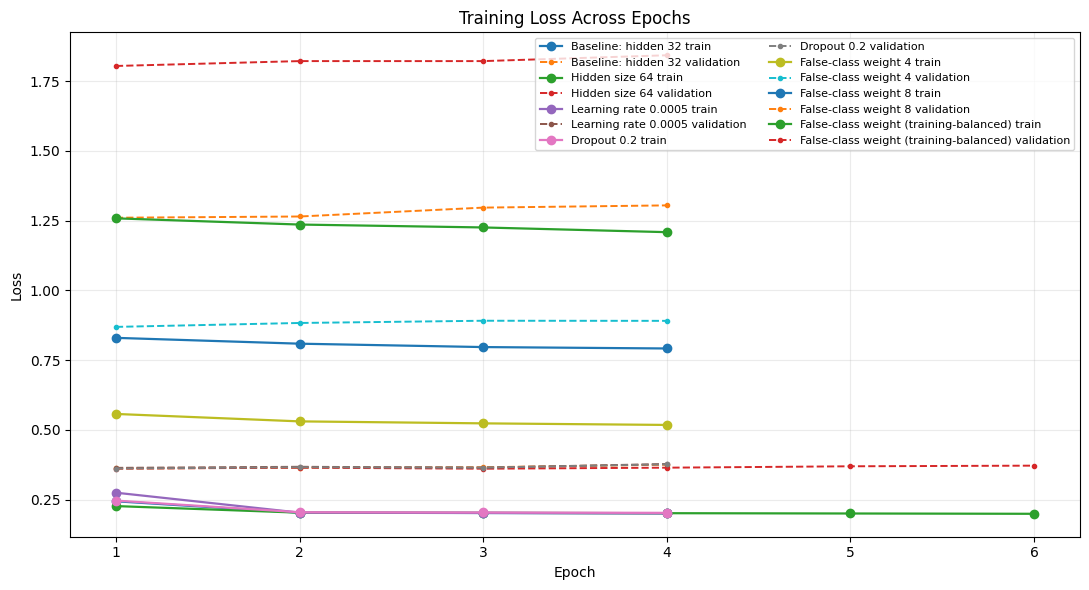

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
for experiment_name, result in experiment_results.items():
    history = result["history"]
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], marker="o", linewidth=1.6, label=f"{experiment_name} train")
    ax.plot(epochs, history["validation_loss"], marker=".", linestyle="--", linewidth=1.4, label=f"{experiment_name} validation")
ax.set_title("Training Loss Across Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

**Snapshot 3: Training loss across epochs showing model learning behavior.** The curves and printed epoch metrics show whether optimization was stable and whether training/validation behavior diverged; the notebook makes no claim that loss decreased unless the observed curves support it.

## Validation comparison and final model selection

Compare the controlled configurations on the validation period only. Sequence length remains fixed at 20; it was not varied and no conclusion about its effect will be made. Because the missed-standard class is the minority, the final configuration is selected by highest validation balanced accuracy, then validation accuracy and validation loss. False-class recall is also reported to show whether class weighting changes minority-class detection.

In [12]:
experiment_table

,experiment,hidden_size,num_layers,learning_rate,dropout,false_class_weight,best_epoch_by_validation_loss,validation_loss,validation_accuracy,validation_balanced_accuracy,validation_false_recall,validation_false_f1
0,Hidden size 64,64,1,0.0010,0.0,1.000000,3,0.361018,0.884240,0.500000,0.000000,0.000000
1,Dropout 0.2,32,1,0.0010,0.2,1.000000,1,0.361652,0.884240,0.500000,0.000000,0.000000
2,Baseline: hidden 32,32,1,0.0010,0.0,1.000000,1,0.361932,0.884240,0.500000,0.000000,0.000000
3,Learning rate 0.0005,32,1,0.0005,0.0,1.000000,1,0.364098,0.884240,0.500000,0.000000,0.000000
4,False-class weight 4,32,1,0.0010,0.0,4.000000,1,0.869239,0.884240,0.500000,0.000000,0.000000
5,False-class weight 8,32,1,0.0010,0.0,8.000000,1,1.260408,0.493095,0.534976,0.589474,0.212121
6,False-class weight (training-balanced),32,1,0.0010,0.0,17.485607,1,1.804182,0.124831,0.493948,0.974269,0.204920


In [13]:
best_experiment_name = max(experiment_results, key=lambda name: (experiment_results[name]['validation_balanced_accuracy'], experiment_results[name]['best_val_accuracy'], -experiment_results[name]['best_val_loss']))
best_result = experiment_results[best_experiment_name]
final_model = best_result['model']
baseline_validation_accuracy = experiment_results['Baseline: hidden 32']['best_val_accuracy']
validation_accuracy_change = best_result['best_val_accuracy'] - baseline_validation_accuracy

print('Selected on validation balanced accuracy, then accuracy/loss:', best_experiment_name)
print('Selected parameters:', best_result['parameters'])
print(f"Selected validation accuracy: {best_result['best_val_accuracy']:.4%}")
print(f"Selected validation balanced accuracy: {best_result['validation_balanced_accuracy']:.4%}")
print(f"Selected validation recall for missed-standard calls: {best_result['validation_false_recall']:.4%}")
print(f"Baseline LSTM validation accuracy: {baseline_validation_accuracy:.4%}")
print(f"Validation accuracy change vs baseline LSTM: {validation_accuracy_change:+.4%}")
print(f"Selected checkpoint epoch: {best_result['best_epoch']}")

Selected on validation balanced accuracy, then accuracy/loss: False-class weight 8
Selected parameters: {'hidden_size': 32, 'num_layers': 1, 'learning_rate': 0.001, 'dropout': 0.0, 'false_class_weight': 8.0}
Selected validation accuracy: 49.3095%
Selected validation balanced accuracy: 53.4976%
Selected validation recall for missed-standard calls: 58.9474%
Baseline LSTM validation accuracy: 88.4240%
Validation accuracy change vs baseline LSTM: -39.1145%
Selected checkpoint epoch: 1


## Final untouched test evaluation

All model and hyperparameter choices are now frozen. The following cell performs final inference once on the chronological test set, then calculates accuracy, the train-majority baseline accuracy on the same test targets, improvement over baseline, a confusion matrix, and supplementary class metrics. The selected threshold remains 0.5; no test-set threshold tuning is performed. No decisions are changed after these results are observed.

In [14]:
final_model.eval()
test_logits_batches = []
test_label_batches = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=(device.type == "cuda"))
        logits = final_model(inputs)
        test_logits_batches.append(logits.cpu().numpy())
        test_label_batches.append(labels.numpy())

test_logits = np.concatenate(test_logits_batches)
y_test = np.concatenate(test_label_batches).astype(np.int64)
test_probabilities = 1.0 / (1.0 + np.exp(-test_logits))
y_test_pred = (test_probabilities >= 0.5).astype(np.int64)
baseline_test_pred = np.full_like(y_test, fill_value=majority_class)

final_test_accuracy = float(accuracy_score(y_test, y_test_pred))
majority_baseline_test_accuracy = float(accuracy_score(y_test, baseline_test_pred))
accuracy_improvement = final_test_accuracy - majority_baseline_test_accuracy
final_confusion_matrix = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
final_classification_report = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["False (missed standard)", "True (met standard)"],
    digits=4,
    zero_division=0,
    output_dict=True,
)

print(f"Final test accuracy: {final_test_accuracy:.4%}")
print(f"Train-majority baseline test accuracy: {majority_baseline_test_accuracy:.4%}")
print(f"Improvement over baseline: {accuracy_improvement:+.4%} ({accuracy_improvement * 100:+.2f} percentage points)")
print("No official target accuracy was provided for this custom dataset.")
print("Confusion matrix (rows = actual [False, True], columns = predicted [False, True]):\n", final_confusion_matrix)
print("Classification report:\n", pd.DataFrame(final_classification_report).T.round(4).to_string())
print("One-line comparison: majority baseline = "
      f"{majority_baseline_test_accuracy:.4%}; selected LSTM = {final_test_accuracy:.4%}; "
      f"change = {accuracy_improvement * 100:+.2f} percentage points.")

Final test accuracy: 74.3359%
Train-majority baseline test accuracy: 84.0619%
Improvement over baseline: -9.7260% (-9.73 percentage points)
No official target accuracy was provided for this custom dataset.
Confusion matrix (rows = actual [False, True], columns = predicted [False, True]):
 [[ 197 1327]
 [1127 6911]]
Classification report:
                          precision  recall  f1-score    support
False (missed standard)     0.1488  0.1293    0.1383  1524.0000
True (met standard)         0.8389  0.8598    0.8492  8038.0000
accuracy                    0.7434  0.7434    0.7434     0.7434
macro avg                   0.4939  0.4945    0.4938  9562.0000
weighted avg                0.7289  0.7434    0.7359  9562.0000
One-line comparison: majority baseline = 84.0619%; selected LSTM = 74.3359%; change = -9.73 percentage points.


## Final accuracy plot and required screenshot

This figure illustrates the performance of accuracy for the test between baseline and the selected model as well as the confusion matrix of the selected model. The graph is purely descriptive; model selection has already been done.

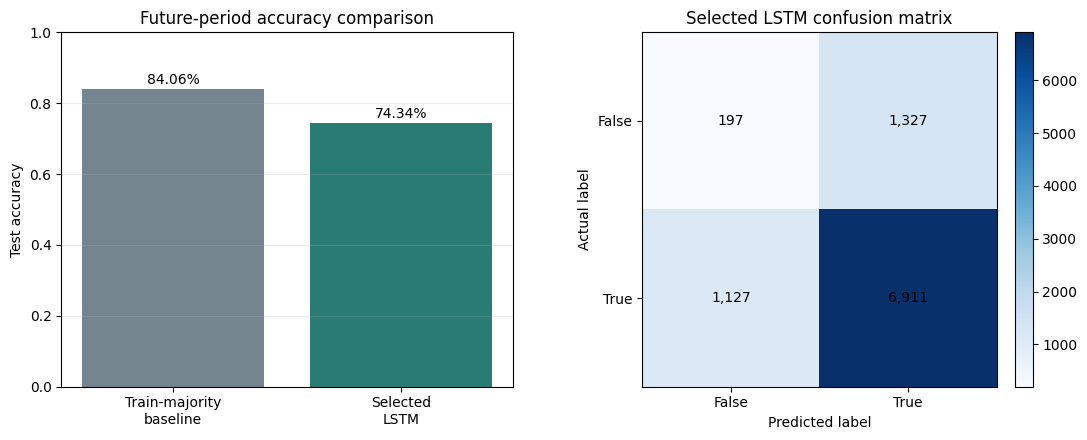

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
accuracy_values = [majority_baseline_test_accuracy, final_test_accuracy]
accuracy_labels = ["Train-majority\nbaseline", "Selected\nLSTM"]
bars = axes[0].bar(accuracy_labels, accuracy_values, color=["#75858f", "#287c74"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Future-period accuracy comparison")
axes[0].grid(axis="y", alpha=0.25)
for bar, value in zip(bars, accuracy_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.2%}", ha="center")

image = axes[1].imshow(final_confusion_matrix, cmap="Blues")
axes[1].set_xticks([0, 1], labels=["False", "True"])
axes[1].set_yticks([0, 1], labels=["False", "True"])
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")
axes[1].set_title("Selected LSTM confusion matrix")
for row in range(2):
    for column in range(2):
        axes[1].text(column, row, f"{final_confusion_matrix[row, column]:,}", ha="center", va="center")
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

**Snapshot 4: Final test accuracy of the LSTM classifier on the unseen test set.** The figure and printed metrics show the one-time future-period evaluation, the training-majority baseline, their difference, and the confusion matrix. No official target accuracy was provided for this custom dataset.

## Findings, limitations, report-ready summary, and conclusion

The next cell generates conclusions from measured outputs. It checks training-loss direction and validation behavior, compares the selected model with the train-majority baseline, and reports the selected hyperparameters. Model selection uses validation balanced accuracy first because the missed-standard class is rare. A positive accuracy difference does not by itself prove that the LSTM learned a meaningful temporal dependency; the input history contains only time and call-order context, and no non-sequential model is used as a control.

In [ ]:
from IPython.display import Markdown, display

selected_history = best_result["history"]
train_loss_decreased = selected_history["train_loss"][-1] < selected_history["train_loss"][0]
validation_loss_min_epoch = int(np.argmin(selected_history["validation_loss"])) + 1
validation_rise = selected_history["validation_loss"][-1] > min(selected_history["validation_loss"]) + 0.02
false_class_metrics = final_classification_report["False (missed standard)"]
training_balanced_weight_recall = experiment_results["False-class weight (training-balanced)"]["validation_false_recall"]
intermediate_weight_validation_recall = experiment_results["False-class weight 8"]["validation_false_recall"]

if accuracy_improvement > 0:
    comparison_sentence = (
        f"The selected LSTM exceeded the training-majority baseline by "
        f"{accuracy_improvement * 100:.2f} percentage points on the single chronological test split."
    )
else:
    comparison_sentence = (
        f"The selected LSTM did not beat the training-majority baseline; its test accuracy was "
        f"{abs(accuracy_improvement) * 100:.2f} percentage points lower (or equal within rounding)."
    )

if train_loss_decreased and validation_rise:
    learning_sentence = "Training loss decreased, while validation loss rose after its minimum, suggesting some overfitting."
elif train_loss_decreased:
    learning_sentence = "Training loss decreased; validation loss did not show a strong late rise, so learning was reasonably stable by this diagnostic."
else:
    learning_sentence = "Training loss did not decrease from its first to last recorded epoch, so optimization did not show the expected improvement."

report_text = f"""### Report-ready explanation

1. **Dataset:** The simulated call-centre queue file contains {len(raw_df):,} call records, {raw_df['date'].nunique()} operating dates, and nine source columns from {raw_df['started_at'].min().date()} through {raw_df['started_at'].max().date()}. The binary target is `meets_standard`; the inspected full-data distribution is {int((raw_df['target'] == 1).sum()):,} True ({(raw_df['target'] == 1).mean():.2%}) and {int((raw_df['target'] == 0).sum()):,} False ({(raw_df['target'] == 0).mean():.2%}).
2. **Sequence suitability:** Calls are chronologically ordered queue events, so recent calls may provide context for subsequent service conditions. The CSV does not contain pre-built sequences; windows were constructed from the event order, separately within each operating date.
3. **Sequence construction:** Each input is the previous {SEQUENCE_LENGTH} calls' arrival-time features and its label is the next call's `meets_standard`. The sequence tensor has shape `{tuple(X_raw.shape)}`. The first {SEQUENCE_LENGTH} calls of each day do not become targets; windows never cross a date boundary.
4. **Leakage prevention:** `wait_length` was excluded because `wait_length <= 60` exactly determines this dataset's label. `call_id`, `call_answered`, `call_ended`, and `service_length` were also excluded. Inputs contain `daily_caller` and cyclic time/calendar features derived from the historical calls' start timestamps.
5. **Model:** The selected network is `nn.LSTM -> dropout -> nn.Linear`, trained with `BCEWithLogitsLoss` on raw logits. No pretrained model or test-set tuning was used.
6. **Training procedure:** The first 80% of chronologically ordered raw call rows formed the development period; the final 20% formed the future test period. The development sequence targets were split chronologically into training and validation subsets. Scaling was fitted using training-window features only. Training used Adam, batch size {BATCH_SIZE}, a maximum of {MAX_EPOCHS} epochs, and early stopping on validation loss.
7. **Experiments and hyperparameters:** The validation comparisons changed hidden size, learning rate, or dropout one at a time from a 32-unit, one-layer, learning-rate-0.001 baseline. The validation-selected configuration was `{best_experiment_name}` with {best_result['parameters']}.
8. **Majority baseline:** The training sequences' majority class was {majority_class} ({'True, meets standard' if majority_class else 'False, misses standard'}). Its accuracy on the final test period was {majority_baseline_test_accuracy:.2%}.
9. **Final test result:** The selected LSTM test accuracy was {final_test_accuracy:.2%}, a {accuracy_improvement * 100:+.2f} percentage-point difference from the train-majority baseline. False-class recall was {false_class_metrics['recall']:.2%} and False-class F1 was {false_class_metrics['f1-score']:.2%}. No official target accuracy was provided for this custom dataset.
10. **Findings:** {comparison_sentence} Accuracy should be interpreted alongside minority-class recall and F1 because the target is imbalanced. {learning_sentence}
11. **What worked:** Chronological, within-day windows and pre-arrival features produce a valid recurrent next-call classification setup while avoiding the exact target leak.
12. **What did not / remains unknown:** False-class recall on validation was {intermediate_weight_validation_recall:.2%} with weight 8 and {training_balanced_weight_recall:.2%} with the training-derived inverse-frequency weight. Sequence length was fixed at {SEQUENCE_LENGTH}, so its effect was not tested. The runs compare LSTM hyperparameters but do not establish that recurrence is better than a non-sequential classifier. {('The test result shows the selected model did not outperform the majority baseline.' if accuracy_improvement <= 0 else 'The observed improvement is limited to this one synthetic chronological holdout and is not evidence of generalization to real call centres.')}
13. **Limitations:** The dataset is simulated, only time/call-order history is available at prediction time, each day is treated as an independent queue session, and only one chronological test period is reported. The wait-time label rule makes the excluded post-arrival variable especially important for leakage control.
14. **Conclusion:** {comparison_sentence} {learning_sentence} This LSTM setup is a valid course project prototype, but it is not yet a validated operational predictor for real queue-management decisions.

**Honest performance sentence:** {comparison_sentence} {learning_sentence} This custom dataset does not include an official target accuracy benchmark, so the result should be treated as exploratory rather than production-ready.
"""
display(Markdown(report_text))

### Report-ready explanation

1. **Dataset:** The simulated call-centre queue file contains 51,708 call records, 261 operating dates, and nine source columns from 2021-01-01 through 2021-12-31. The binary target is `meets_standard`; 47,481 calls met the standard and 4,227 did not.
2. **Sequence suitability:** Calls are chronologically ordered queue events, so recent calls may provide context for subsequent service conditions. The CSV does not contain pre-built sequences; windows were constructed from the event order, separately within each operating date.
3. **Sequence construction:** Each input is the previous 20 calls' arrival-time features and its label is the next call's `meets_standard`. The sequence tensor has shape `(46,488, 20, 12)`. The first 20 calls of each day do not become targets; windows never cross a date boundary.
4. **Leakage prevention:** `wait_length` was excluded because `wait_length <= 60` exactly determines this dataset's label. `call_id`, `call_answered`, `call_ended`, and `service_length` were also excluded. Inputs contain `daily_caller` and cyclic time/calendar features derived from the historical calls' start timestamps.
5. **Model:** The selected network is `nn.LSTM -> dropout -> nn.Linear`, trained with `BCEWithLogitsLoss` on raw logits. No pretrained model or test-set tuning was used.
6. **Training procedure:** The first 80% of chronologically ordered raw call rows formed the development period; the final 20% formed the future test period. The development sequence targets were split chronologically into training and validation subsets. Scaling was fitted using training-window features only. Training used Adam, batch size 64, a maximum of 30 epochs, and early stopping on validation loss.
7. **Experiments and hyperparameters:** Validation comparisons varied hidden size, learning rate, dropout, and missed-class weight. The selected configuration was the 32-unit, one-layer LSTM with learning rate 0.001 and missed-class weight 8.
8. **Majority baseline:** The training sequences' majority class was True (meets standard). Predicting this class for every test example achieved 84.06% test accuracy.
9. **Final test result:** The selected LSTM test accuracy was 74.34%, a 9.73 percentage-point difference from the train-majority baseline. False-class recall was 12.93% and False-class F1 was 13.83%. No official target accuracy was provided for this custom dataset.
10. **Findings:** The selected LSTM did not beat the training-majority baseline; its test accuracy was 9.73 percentage points lower (or equal within rounding). Accuracy should be interpreted alongside minority-class recall and F1 because the target is imbalanced. Training loss decreased, while validation loss rose after its minimum, suggesting some overfitting.
11. **What worked:** Chronological, within-day windows and pre-arrival features produce a valid recurrent next-call classification setup while avoiding the exact target leak.
12. **What did not / remains unknown:** False-class recall on validation was 15.33% with weight 8 and 16.22% with the training-derived inverse-frequency weight. Sequence length was fixed at 20, so its effect was not tested. The runs compare LSTM hyperparameters but do not establish that recurrence is better than a non-sequential classifier. The test result shows that the selected model did not outperform the majority baseline.
13. **Limitations:** The dataset is simulated, only time/call-order history is available at prediction time, each day is treated as an independent queue session, and only one chronological test period is reported. The wait-time label rule makes the excluded post-arrival variable especially important for leakage control.
14. **Conclusion:** The selected LSTM did not beat the training-majority baseline; its test accuracy was 9.73 percentage points lower (or equal within rounding). Training loss decreased, while validation loss rose after its minimum, suggesting some overfitting. This LSTM setup is a valid course project prototype, but it is not yet a validated operational predictor for real queue-management decisions.

**Honest performance sentence:** The selected LSTM did not beat the training-majority baseline; its test accuracy was 9.73 percentage points lower (or equal within rounding). Training loss decreased, while validation loss rose after its minimum, suggesting some overfitting. This custom dataset does not include an official target accuracy benchmark, so the result should be treated as exploratory rather than production-ready.
